In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [8]:
df = pd.read_excel("yigitdsa210data.xlsx")
df.head()

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,Gls,Ast,G+A,Gls.1,Ast.1,Market Value
0,Miguel Almirón,py PAR,FW,Newcastle United,30.0,1994.0,9.0,1,157.000,0.0,0.0,0.0,0.00,0.00,€18.00m
1,Michail Antonio,jm JAM,FW,West Ham United,34.0,1990.0,14.0,11,836.000,1.0,1.0,2.0,0.11,0.11,€6.00m
2,Antony,br BRA,"FW,MF",Manchester Utd,24.0,2000.0,8.0,0,141.000,0.0,0.0,0.0,0.00,0.00,€40.00m
3,Cameron Archer,eng ENG,FW,Southampton,23.0,2001.0,35.0,13,1.441,2.0,0.0,2.0,0.12,0.00,€18.00m
4,Adam Armstrong,eng ENG,"FW,MF",Southampton,27.0,1997.0,20.0,15,1.248,2.0,2.0,4.0,0.14,0.14,€18.00m


In [9]:
def convert_market_value(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = x.replace("€", "").lower()

    if x.endswith("m"):
        return float(x[:-1]) * 1000000
    elif x.endswith("k"):
        return float(x[:-1]) * 1000
    else:
        return float(x)

df["Market Value Numeric"] = df["Market Value"].apply(convert_market_value)

In [10]:
numeric_columns = ["Age", "MP", "Starts", "Min", "Gls", "Ast", "G+A", "Market Value Numeric"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=numeric_columns)

In [11]:
df[["Gls", "Ast", "G+A", "Market Value Numeric"]].head()

,Gls,Ast,G+A,Market Value Numeric
0,0.0,0.0,0.0,18000000.0
1,1.0,1.0,2.0,6000000.0
2,0.0,0.0,0.0,40000000.0
3,2.0,0.0,2.0,18000000.0
4,2.0,2.0,4.0,18000000.0


Hypothesis

I want to see if player performance affects market value.

H0: Performance does not affect market value  
H1: Performance affects market value

In [12]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["G+A"], df["Market Value Numeric"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.4404282327592456
P-value: 2.580544136825974e-06


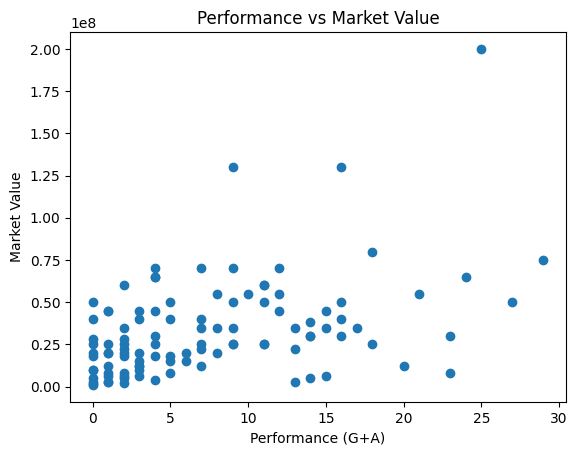

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df["G+A"], df["Market Value Numeric"])
plt.xlabel("Performance (G+A)")
plt.ylabel("Market Value")
plt.title("Performance vs Market Value")
plt.show()

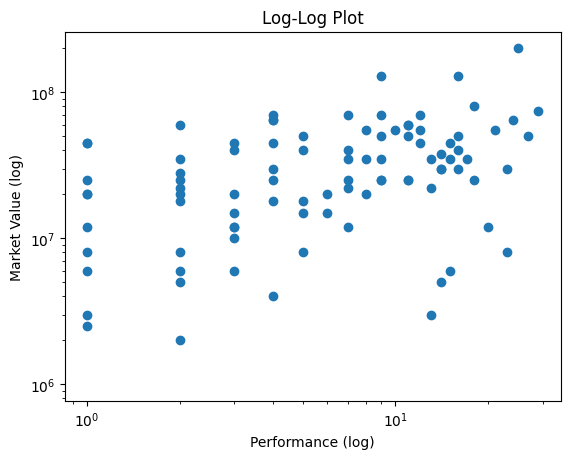

In [14]:
plt.scatter(df["G+A"], df["Market Value Numeric"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Performance (log)")
plt.ylabel("Market Value (log)")
plt.title("Log-Log Plot")
plt.show()

The correlation between performance (G+A) and market value is moderately positive.

This shows that players who score and assist more generally have higher market values.

The p-value is very small, which means the relationship is statistically significant and not due to random chance.

The scatter plot shows a general upward trend, but also some variation between players.

The log-log plot makes the relationship clearer by reducing the effect of extreme values.

This suggests that performance is an important factor in determining market value, but other factors such as age, team, and popularity may also play a role.